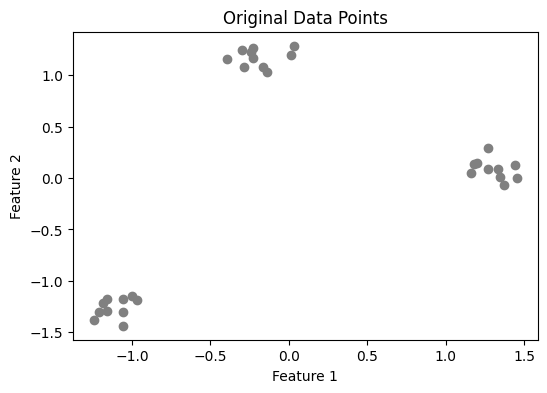

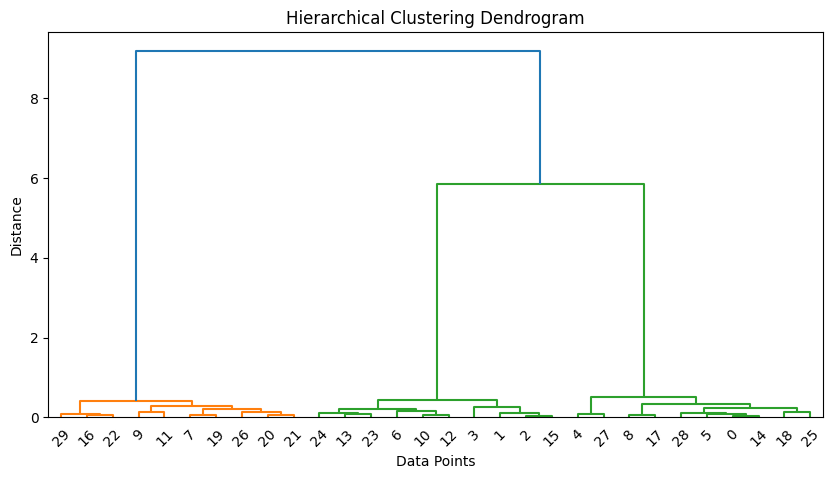

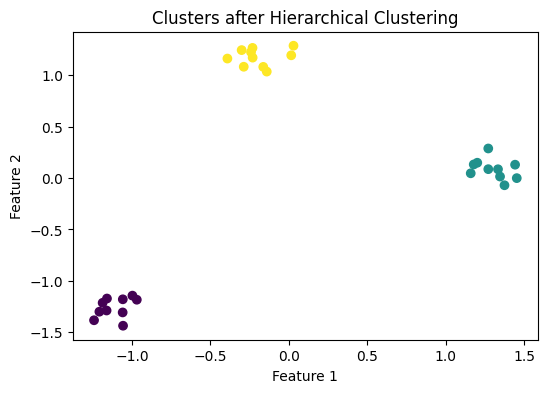

Data Point 1 -> Cluster 3
Data Point 2 -> Cluster 2
Data Point 3 -> Cluster 2
Data Point 4 -> Cluster 2
Data Point 5 -> Cluster 3
Data Point 6 -> Cluster 3
Data Point 7 -> Cluster 2
Data Point 8 -> Cluster 1
Data Point 9 -> Cluster 3
Data Point 10 -> Cluster 1
Data Point 11 -> Cluster 2
Data Point 12 -> Cluster 1
Data Point 13 -> Cluster 2
Data Point 14 -> Cluster 2
Data Point 15 -> Cluster 3
Data Point 16 -> Cluster 2
Data Point 17 -> Cluster 1
Data Point 18 -> Cluster 3
Data Point 19 -> Cluster 3
Data Point 20 -> Cluster 1
Data Point 21 -> Cluster 1
Data Point 22 -> Cluster 1
Data Point 23 -> Cluster 1
Data Point 24 -> Cluster 2
Data Point 25 -> Cluster 2
Data Point 26 -> Cluster 3
Data Point 27 -> Cluster 1
Data Point 28 -> Cluster 3
Data Point 29 -> Cluster 3
Data Point 30 -> Cluster 1


In [ ]:
# -----------------------------------------
# Hierarchical Clustering Demonstration
# -----------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# -----------------------------------------
# Step 1: Generate Sample Data
# -----------------------------------------
# We create synthetic data with clear cluster structure

X, y_true = make_blobs(
    n_samples=30,
    centers=3,
    cluster_std=0.6,
    random_state=42
)

# Standardize the data (important for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Plot raw data
plt.figure(figsize=(6, 4))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c='gray')
plt.title("Original Data Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Step 2: Compute Distance Matrix

#Hierarchical clustering is based on distance between points

distance_matrix = pdist(X_scaled, metric='euclidean')

# Step 3: Perform Hierarchical Clustering

# Common linkage methods: single, complete, average, ward

linkage_matrix = linkage(
    distance_matrix,
    method='ward'
)

# Step 4: Plot Dendrogram

# Dendrogram shows how clusters are merged

plt.figure(figsize=(10, 5))
dendrogram(
    linkage_matrix,
    truncate_mode=None
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


# Step 5: Form Flat Clusters

# Cut the dendrogram to get a fixed number of clusters

num_clusters = 3

clusters = fcluster(
    linkage_matrix,
    t=num_clusters,
    criterion='maxclust'
)


# Step 6: Visualize Final Clusters


plt.figure(figsize=(6, 4))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    cmap='viridis'
)
plt.title("Clusters after Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# Step 7: Print Cluster Assignment


for i, cluster_id in enumerate(clusters):
    print(f"Data Point {i + 1} -> Cluster {cluster_id}")
